### [주제 : 사과 & 바나나 분류 - (4) Unknown 탐지 포함 예측]
- **모델 : SVC (kernel=linear, probability=True)**
- **Unknown 탐지 : predict_proba() 임계값 방식**
- 사과/바나나가 아닌 이미지는 'unknown' 으로 분류

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report

#### [1] 데이터 로드 및 전처리

In [2]:
df = pd.read_csv('./fruit_data.csv')

x = df.iloc[:, :-1].values / 255.0   # 정규화
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'train: {X_train.shape}, test: {X_test.shape}')

train: (350, 10000), test: (88, 10000)


#### [2] 모델 학습
- `probability=True` : predict_proba() 사용을 위해 필수
- SVC는 기본적으로 확률을 제공하지 않으므로 반드시 설정

In [3]:
model = SVC(kernel='linear', probability=True, random_state=42)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score  = model.score(X_test,  y_test)

print(f'TRAIN 정확도: {train_score:.4f}')
print(f'TEST  정확도: {test_score:.4f}')

TRAIN 정확도: 1.0000
TEST  정확도: 0.7955


#### [3] 평가 리포트

In [4]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       0.75      0.89      0.82        45
      banana       0.86      0.70      0.77        43

    accuracy                           0.80        88
   macro avg       0.81      0.79      0.79        88
weighted avg       0.80      0.80      0.79        88



#### [4] Unknown 탐지 함수
- `predict_proba()` 로 각 클래스 확률 반환
- 최대 확률이 threshold 미만이면 'unknown' 처리
- threshold 기본값 0.7 (70% 이상 확신할 때만 분류)

In [5]:
def predict_with_unknown(model, data, threshold=0.7):
    """
    data      : 2D array (n_samples, n_features)
    threshold : 이 값 미만이면 'unknown' 반환
    """
    proba  = model.predict_proba(data)    # shape: (n, 2)
    preds  = model.predict(data)          # shape: (n,)
    max_p  = proba.max(axis=1)            # 각 샘플의 최대 확률

    result = [
        pred if prob >= threshold else 'unknown'
        for pred, prob in zip(preds, max_p)
    ]
    return result, max_p

#### [5] 새 이미지 변환 함수

In [6]:
def convert_data(filepath):
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f'이미지를 읽을 수 없습니다: {filepath}')
    res = cv2.resize(img, (100, 100))
    return (res / 255.0).flatten()    # (10000,)

#### [6] 새 이미지 예측 (Unknown 포함)

In [7]:
files = ['./apple01.png', './banana.jpg', './pear2.jpg', './pear3.jpg']

new_data = np.array([convert_data(f) for f in files])   # (n, 10000)

results, probas = predict_with_unknown(model, new_data, threshold=0.7)

for f, pred, prob in zip(files, results, probas):
    filename = f.split('/')[-1]
    print(f'{filename:20s} => 예측: {pred:10s} (확률: {prob:.2%})')

apple01.png          => 예측: apple      (확률: 88.51%)
banana.jpg           => 예측: unknown    (확률: 57.80%)
pear2.jpg            => 예측: unknown    (확률: 55.66%)
pear3.jpg            => 예측: apple      (확률: 76.43%)


#### [7] 시각화

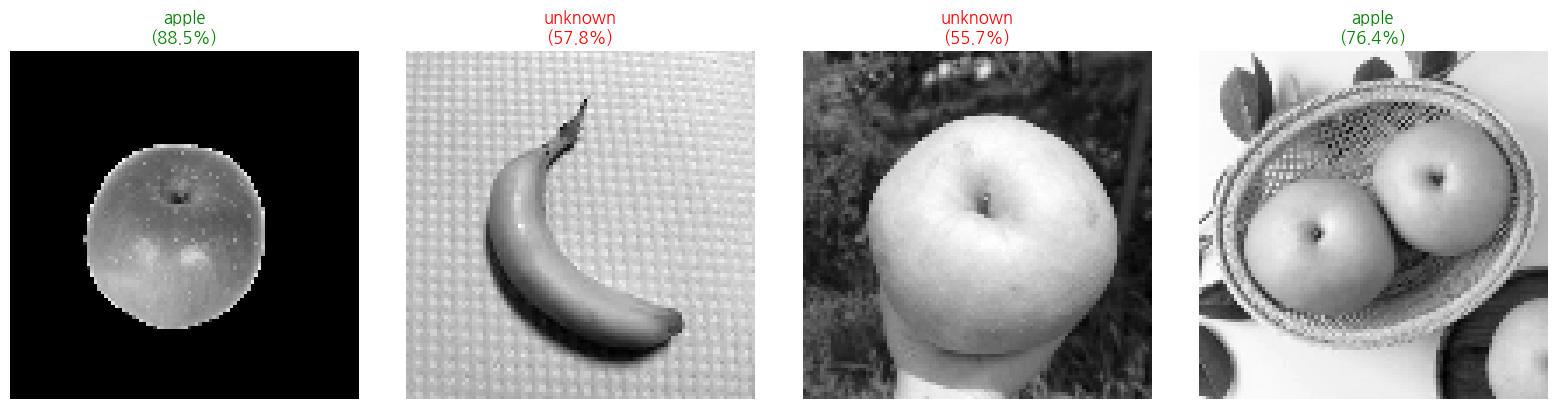

In [8]:
n = len(files)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

for i, ax in enumerate(axes):
    ax.imshow(new_data[i].reshape(100, 100), cmap='gray')
    color = 'green' if results[i] != 'unknown' else 'red'
    ax.set_title(f'{results[i]}\n({probas[i]:.1%})', color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

#### [8] threshold 값에 따른 결과 비교

In [9]:
print(f'{"파일명":20s}  ', end='')
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
for t in thresholds:
    print(f'  t={t}  ', end='')
print()
print('-' * 80)

for i, f in enumerate(files):
    filename = f.split('/')[-1]
    print(f'{filename:20s}  ', end='')
    for t in thresholds:
        res, _ = predict_with_unknown(model, new_data[i].reshape(1, -1), threshold=t)
        print(f'{res[0]:10s}', end='')
    print()

파일명                     t=0.5    t=0.6    t=0.7    t=0.8    t=0.9  
--------------------------------------------------------------------------------
apple01.png           apple     apple     apple     apple     unknown   
banana.jpg            banana    unknown   unknown   unknown   unknown   
pear2.jpg             apple     unknown   unknown   unknown   unknown   
pear3.jpg             apple     apple     apple     unknown   unknown   
